# 1. Import & Setup

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import sys
from sklearn.impute import SimpleImputer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
# Versions-Management
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")

# Warnings kontrollieren
warnings.filterwarnings('ignore', category=FutureWarning)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Pandas: 2.3.3


# 2. Daten einlesen

In [58]:
file_path = "../data/Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df = pd.read_csv(file_path, sep=";", header=1, encoding="ISO-8859-1")

# 3. Datenbereinigung

In [59]:
# Spaltennamen aufräumen
df.columns = df.columns.str.strip()

# NUR British Columbia behalten
df = df[df["Jurisdiction"] == "British Columbia"].copy()

# "Data Qualifier"-Spalte entfernen
df = df.loc[:, ~df.columns.str.contains('Data Qualifier', case=False)]

# Alle 'Unspecified'-Einträge in 'Month' löschen
df = df[df["Month"].notna()]
df = df[~df['Month'].str.contains("Unspecified", case=False, na=False)]

# Alle leeren Werte durch NaN ersetzen
df = df.replace(["", " ",], np.nan)

# "Wide" → "Long" Format
df_long = df.melt(
    id_vars=["Jurisdiction", "Month"],  # diese Spalten bleiben fix
    var_name="Year",                    # Name der neuen "Jahr"-Spalte
    value_name="Number_fires"                  # Name für die Werte (z. B. Anzahl Brände)
)

#Month als 1–12 umwandeln
df_long["Month"] = pd.to_datetime(df_long["Month"], format="%B").dt.month

In [ ]:
# Für Korrelationsanalyse Rohdatei speichern
#output_path = "../data/cleaned_wlags_Number_of_fires_by_month.csv"
#df_long.to_csv(output_path, index=False)

# 4. Explorative Visualisierung

Basisinfo

In [60]:
print(df_long.info())
print(df_long.describe())

# Fehlende Werte je Spalte
print(df_long.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Jurisdiction  408 non-null    object 
 1   Month         408 non-null    int32  
 2   Year          408 non-null    object 
 3   Number_fires  368 non-null    float64
dtypes: float64(1), int32(1), object(2)
memory usage: 11.3+ KB
None
            Month  Number_fires
count  408.000000    368.000000
mean     6.500000    166.589674
std      3.456291    263.983604
min      1.000000      1.000000
25%      3.750000      6.750000
50%      6.500000     78.500000
75%      9.250000    193.250000
max     12.000000   2118.000000
Jurisdiction     0
Month            0
Year             0
Number_fires    40
dtype: int64


Zeitreihen Visualisierung

Saisonale Muster

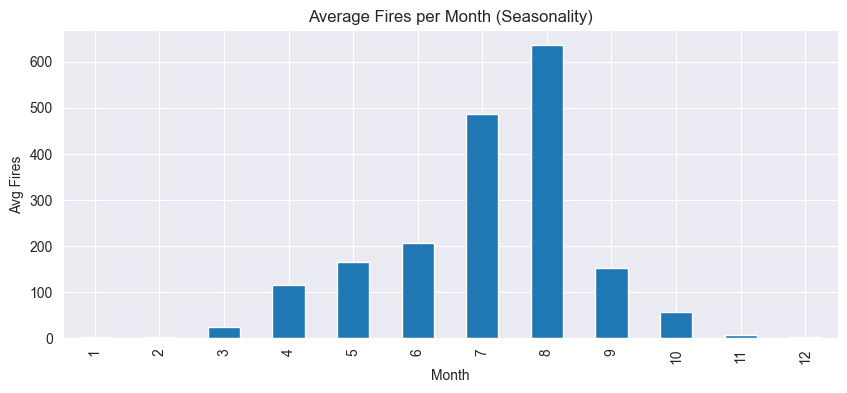

In [61]:
monthly_avg = df_long.groupby("Month")["Number_fires"].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Fires per Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Fires")
plt.show()


<Figure size 1200x500 with 0 Axes>

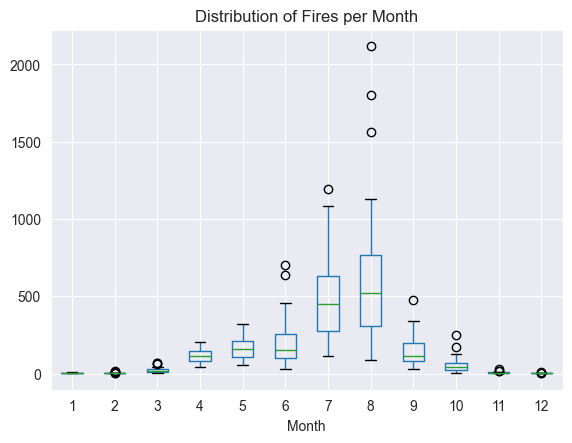

In [62]:
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.title("Distribution of Fires per Month")
plt.suptitle("")
plt.show()

<Figure size 1200x500 with 0 Axes>

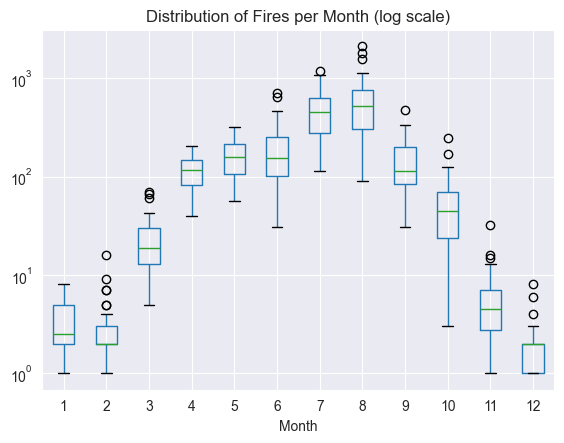

In [63]:
#Log-Skala
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.yscale("log")
plt.title("Distribution of Fires per Month (log scale)")
plt.suptitle("")
plt.show()

Heatmap Jahr x Monat

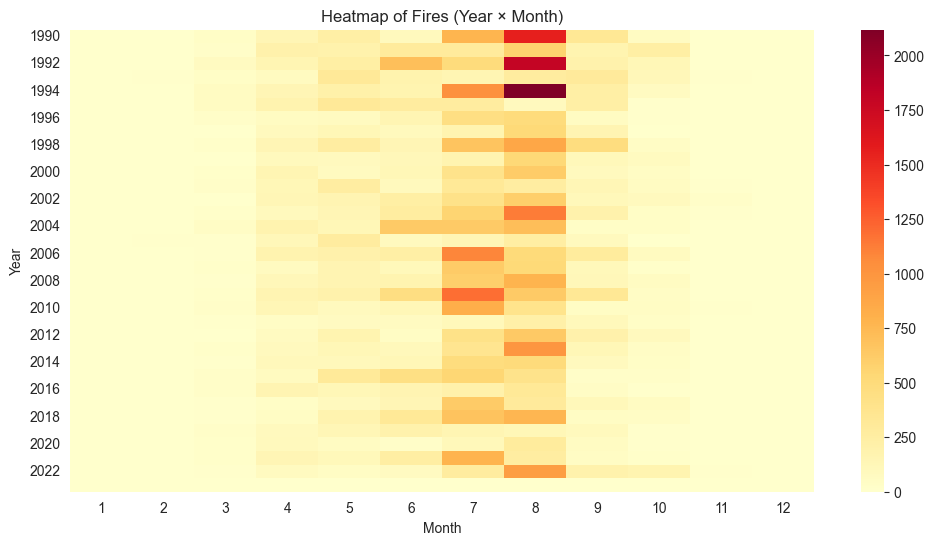

In [64]:
pivot = df_long.pivot_table(
    index="Year",
    columns="Month",
    values="Number_fires",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heatmap of Fires (Year × Month)")
plt.show()

Autokorrelation

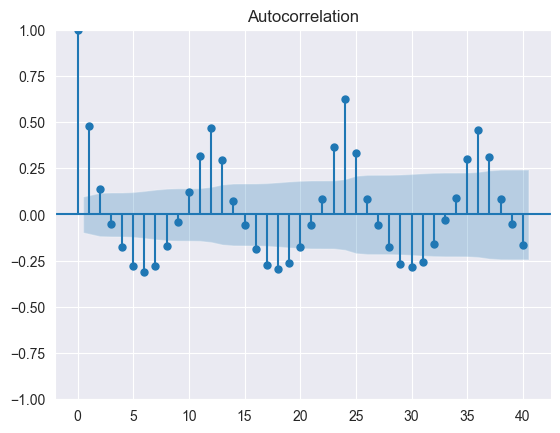

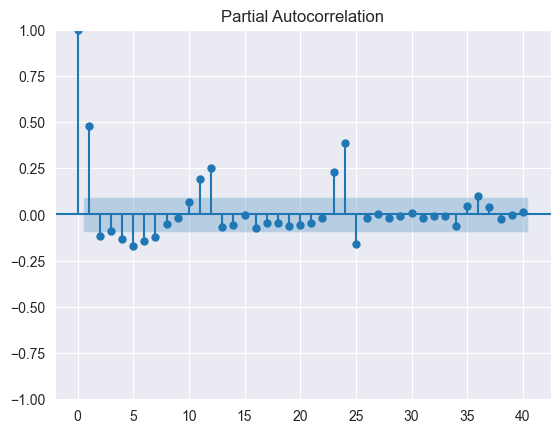

In [65]:
# Kanada-gesamt Zeitreihe
ts_total_sorted = ts_total.sort_values("Date")

plot_acf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

plot_pacf(ts_total_sorted["Number_fires"].dropna(), lags=40)
plt.show()

Ausreißer identifizieren

<Figure size 1200x600 with 0 Axes>

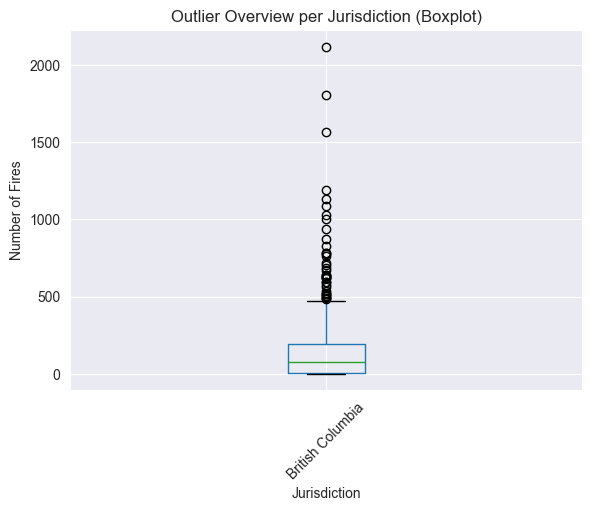

In [66]:
plt.figure(figsize=(12,6))
df_long.boxplot(column="Number_fires", by="Jurisdiction", rot=45)
plt.title("Outlier Overview per Jurisdiction (Boxplot)")
plt.suptitle("")
plt.xlabel("Jurisdiction")
plt.ylabel("Number of Fires")
plt.show()

# 5. Feature Engineering

In [67]:
# Datentypen anpassen
df_long["Year"] = df_long["Year"].astype(int)

# Anzahl (Number_fires) als ganze Zahl
df_long["Number_fires"] = pd.to_numeric(df_long["Number_fires"], errors="coerce").astype("Int64")

df_long = df_long.sort_values(["Year", "Month"])

df_long["Lag_1"] = df_long["Number_fires"].shift(1)
df_long["Lag_2"] = df_long["Number_fires"].shift(2)
df_long["Lag_3"] = df_long["Number_fires"].shift(3)

df_long["RollMean_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .mean()
)
df_long["RollStd_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .std()
)
df_long["RollSum_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .sum()
)

# Saisonale Indikatoren (Regime)
df_long["is_summer"] = df_long["Month"].isin([6, 7, 8]).astype(int)

# Trigonometrisches Encoding für Monat (1–12)
df_long["Month_sin"] = np.sin(2 * np.pi * df_long["Month"] / 12)
df_long["Month_cos"] = np.cos(2 * np.pi * df_long["Month"] / 12)

# Kontrolle
df_long[["Month", "Month_sin", "Month_cos"]].head(12)
df_long[["Number_fires", "Lag_1", "RollMean_3"]].head(15)
print(df_long.head(20))
print(df_long.dtypes)
df_fires = df_long.copy()

        Jurisdiction  Month  Year  Number_fires  Lag_1  Lag_2  Lag_3  \
0   British Columbia      1  1990          <NA>   <NA>   <NA>   <NA>   
1   British Columbia      2  1990             3   <NA>   <NA>   <NA>   
2   British Columbia      3  1990            35      3   <NA>   <NA>   
3   British Columbia      4  1990           147     35      3   <NA>   
4   British Columbia      5  1990           235    147     35      3   
5   British Columbia      6  1990            95    235    147     35   
6   British Columbia      7  1990           775     95    235    147   
7   British Columbia      8  1990          1563    775     95    235   
8   British Columbia      9  1990           336   1563    775     95   
9   British Columbia     10  1990            60    336   1563    775   
10  British Columbia     11  1990             6     60    336   1563   
11  British Columbia     12  1990          <NA>      6     60    336   
12  British Columbia      1  1991             2   <NA>      6   

In [ ]:
#Datei speichern
#output_path = "../data/cleaned_Number_of_fires_by_month.csv"
#df_long.to_csv(output_path, index=False)

# 6. Wetterdaten Bereinigung

In [68]:
# Spalte time löschen und type ändern
df_weather = pd.read_csv(
    "../data/cleaned_British_Columbia_monthly_mean.csv"
)
if "time" in df_weather.columns:
   df_weather = df_weather.drop(columns=["time"])

df_weather["Year"] = df_weather["Year"].astype(int)
df_weather["Month"] = df_weather["Month"].astype(int)

print(df_weather.shape)
print(df_weather.columns)

(397, 12)
Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month'],
      dtype='object')


In [69]:
# Spalten löschen aufgrund der Korrel. Analyse (Finale Feature Definition)
cols_to_drop = [
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)"
]

df_weather = df_weather.drop(
    columns=[c for c in cols_to_drop if c in df_weather.columns]
)
print(df_weather.columns)
print(df_weather.dtypes)

Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'et0_fao_evapotranspiration (mm)', 'Year', 'Month'],
      dtype='object')
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
relative_humidity_2m_mean (%)      float64
relative_humidity_2m_min (%)       float64
et0_fao_evapotranspiration (mm)    float64
Year                                 int64
Month                                int64
dtype: object


In [70]:
df_weather_lag = df_weather.sort_values(["Year", "Month"]).copy()
weather_cols = [c for c in df_weather_lag.columns if c not in ["Year", "Month"]]
df_weather_lag[weather_cols] = df_weather_lag[weather_cols].shift(1)

# 6a. Merge Wetterdaten & Anzahl Brände

In [71]:
# Merge
df_merged = pd.merge(
    df_fires,
    df_weather_lag,
    on=["Year", "Month"],
    how="inner"
).dropna().reset_index(drop=True)

print(df_merged.shape)
print(df_merged.isna().sum())
print(df_merged.head())

(300, 18)
Jurisdiction                       0
Month                              0
Year                               0
Number_fires                       0
Lag_1                              0
Lag_2                              0
Lag_3                              0
RollMean_3                         0
RollStd_3                          0
RollSum_3                          0
is_summer                          0
Month_sin                          0
Month_cos                          0
temperature_2m_mean (°C)           0
temperature_2m_max (°C)            0
relative_humidity_2m_mean (%)      0
relative_humidity_2m_min (%)       0
et0_fao_evapotranspiration (mm)    0
dtype: int64
       Jurisdiction  Month  Year  Number_fires  Lag_1  Lag_2  Lag_3  \
0  British Columbia      5  1990           235    147     35      3   
1  British Columbia      6  1990            95    235    147     35   
2  British Columbia      7  1990           775     95    235    147   
3  British Columbia      8 

# 7. Feature Engineering Wetterdaten + Vorbereitung für den Split

In [72]:
df_merged = df_merged.sort_values(["Year", "Month"])

weather_features = [
    "temperature_2m_mean (°C)",
    "relative_humidity_2m_mean (%)",
    "relative_humidity_2m_min (%)",
    "et0_fao_evapotranspiration (mm)",
    "temperature_2m_max (°C)"
]

for col in weather_features:
    df_merged[f"{col}_lag1"] = df_merged[col].shift(1)

# Zeitgleiche Wetterdaten entfernen
df_merged = df_merged.drop(columns=weather_features)

# NaNs durch Lag entfernen
df_merged = df_merged.dropna().reset_index(drop=True)

In [73]:
# Number of fires als Zielvariabel setzen und NaNs in Number of fires löschen
target = "Number_fires"
df_model = df_merged[df_merged[target].notna()].copy()
df_model.to_csv("../data/final_data_v4_bc.csv", index=False)

In [74]:
#df_model = pd.read_csv("../data/final_data.csv")

target = "Number_fires"

X = df_model.drop(columns=[target])
y = df_model[target]

# 8. Train/ Test Split

In [75]:
# Training: ca. 60% der Zeit (1990–2012), Validation: ca. 20 % (2013–2017), Test: ca. 20 % (2018–2023)

mask_train = df_model["Year"] <= 2012
mask_val   = (df_model["Year"] > 2012) & (df_model["Year"] <= 2017)
mask_test  = df_model["Year"] > 2017

# Feature-Liste (Year explizit entfernen!)
feature_cols = [
    c for c in df_model.columns
    if c not in [target, "Year"]
]

X = df_model[feature_cols]
y = df_model[target]

# Zeitbasierter Split
X_train = X.loc[mask_train].copy()
y_train = y.loc[mask_train].copy()

X_val = X.loc[mask_val].copy()
y_val = y.loc[mask_val].copy()

X_test = X.loc[mask_test].copy()
y_test = y.loc[mask_test].copy()

# Imputation (nur numerische Features)
num_cols = X_train.select_dtypes(include=["number"]).columns

imputer = SimpleImputer(strategy="median")

X_train.loc[:, num_cols] = imputer.fit_transform(X_train.loc[:, num_cols])
X_val.loc[:, num_cols]   = imputer.transform(X_val.loc[:, num_cols])
X_test.loc[:, num_cols]  = imputer.transform(X_test.loc[:, num_cols])

# Imputer für Backend speichern
joblib.dump(imputer, "../backend/imputer_bc.joblib")
print("IMPUTER GESPEICHERT")

# Konsistenz-Checks
print("Train max year:", df_model.loc[mask_train, "Year"].max())
print("Test min year:", df_model.loc[mask_test, "Year"].min())

assert target not in X_train.columns
assert len(X_train) == len(y_train)
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

IMPUTER GESPEICHERT
Train max year: 2012
Test min year: 2018


In [76]:
# Jurisdiction entfernen
X_train = X_train.drop(columns=["Jurisdiction"])
X_val   = X_val.drop(columns=["Jurisdiction"])
X_test  = X_test.drop(columns=["Jurisdiction"])

# 9. Baseline trainieren - Random Forest

In [77]:
#Random-Forest-Baseline definieren
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [78]:
#Modell trainieren
rf_baseline.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
#Vorhersage trainieren
y_pred_train = rf_baseline.predict(X_train)
y_pred_val   = rf_baseline.predict(X_val)
y_pred_test  = rf_baseline.predict(X_test)

# 10. Baseline Modell evaluieren - Random Forest

In [80]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val,   y_pred_val,   "Validation")
evaluate(y_test,  y_pred_test,  "Test")


Train → MAE: 38.21, RMSE: 71.43
Validation → MAE: 97.95, RMSE: 182.30
Test → MAE: 113.18, RMSE: 190.54


# 9a Baseline trainieren - XGBoost

In [81]:
# Baseline definieren MIT Early Stopping
xgb_baseline = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    early_stopping_rounds=20,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Baseline Modell trainieren (MIT eval_set!)
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


In [82]:
#Vorhersagen erzeugen
y_pred_train_xgb = xgb_baseline.predict(X_train)
y_pred_val_xgb   = xgb_baseline.predict(X_val)
y_pred_test_xgb  = xgb_baseline.predict(X_test)

# 10a Baseline evaluieren - XG Boost

In [83]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train_xgb, "Train")
evaluate(y_val,   y_pred_val_xgb,   "Validation")
evaluate(y_test,  y_pred_test_xgb,  "Test")


Train → MAE: 94.60, RMSE: 174.16
Validation → MAE: 99.64, RMSE: 143.38
Test → MAE: 120.07, RMSE: 173.01


In [84]:
# Fehleranalyse – Single-Region-Modell (BC)

test_errors = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_test_xgb,
    "error": np.abs(y_test.values - y_pred_test_xgb),
    "Year": df_model.loc[y_test.index, "Year"].values
})

print("\nGrößte Fehler:")
print(
    test_errors
    .nlargest(10, "error")[["actual", "predicted", "error", "Year"]]
)

print("\nFehler-Statistiken:")
print(f"Median Error: {test_errors['error'].median():.2f}")
print(f"90th Percentile Error: {test_errors['error'].quantile(0.9):.2f}")



Größte Fehler:
    actual   predicted       error  Year
32     935  282.538666  652.461334  2022
1      684  342.521454  341.478546  2018
10     126  451.036438  325.036438  2019
23     784  477.645172  306.354828  2021
24     263  543.409302  280.409302  2021
9      155  385.911072  230.911072  2019
15     115  316.835663  201.835663  2020
3       52  214.930435  162.930435  2018
0      327  177.039795  149.960205  2018
25      53  193.331924  140.331924  2021

Fehler-Statistiken:
Median Error: 69.62
90th Percentile Error: 290.79


# 11. Modellauswahl

Obwohl der Random-Forest-Regressor als Baseline-Modell eine vergleichsweise gute Trainingsleistung erzielte, zeigte er eine ausgeprägte Überanpassung und eine eingeschränkte Generalisierungsfähigkeit. Aufgrund dieser strukturellen Limitationen wurde Random Forest nicht weiter optimiert, sondern durch leistungsfähigere Boosting-Modelle ersetzt.

# 12. Optimierung

In [85]:
#Hyperparameter Tuning
configs = {
    "baseline": {
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 1
    },
    "regularized_depth5": {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 3
    },
    "regularized_depth4": {
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 5
    }
}


In [86]:
#Evaluation
results = []

for name, cfg in configs.items():
    model = XGBRegressor(
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **cfg
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append((name, mae, rmse))

    print(f"{name} → Val MAE: {mae:.2f}, Val RMSE: {rmse:.2f}")


baseline → Val MAE: 101.15, Val RMSE: 175.74
regularized_depth5 → Val MAE: 112.39, Val RMSE: 197.20
regularized_depth4 → Val MAE: 112.37, Val RMSE: 202.52


# 13. Training & Evaluation

In [87]:
# Train + Validation zusammenführen
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final, y_final)

y_test_pred = final_model.predict(X_test)

In [88]:
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Final Model – Test MAE:  {mae_test:.2f}")
print(f"Final Model – Test RMSE: {rmse_test:.2f}")

Final Model – Test MAE:  113.98
Final Model – Test RMSE: 177.21


# 14. Interpretation & Ergebnisse

In [90]:
#Feature Importance
importance = final_model.get_booster().get_score(importance_type="gain")

# In DataFrame umwandeln
imp_df = (
    pd.DataFrame(importance.items(), columns=["Feature", "Gain"])
    .sort_values(by="Gain", ascending=False)
)
print(imp_df.head(15))

                                 Feature           Gain
7                              is_summer  733538.125000
9                              Month_cos  113744.937500
8                              Month_sin  108154.976562
3                                  Lag_3   65372.500000
1                                  Lag_1   34391.363281
6                              RollSum_3   26443.781250
14          temperature_2m_max (°C)_lag1   25951.433594
13  et0_fao_evapotranspiration (mm)_lag1   24059.625000
4                             RollMean_3   23498.027344
5                              RollStd_3   22917.507812
0                                  Month   22205.060547
10         temperature_2m_mean (°C)_lag1   18010.013672
12     relative_humidity_2m_min (%)_lag1   14653.596680
11    relative_humidity_2m_mean (%)_lag1   14392.466797
2                                  Lag_2   13454.409180


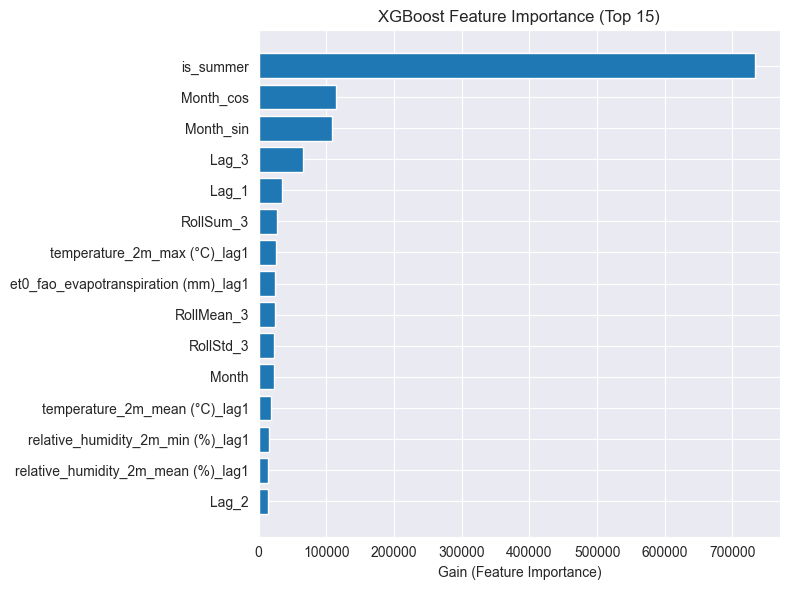

In [91]:
top_n = 15
plt.figure(figsize=(8, 6))
plt.barh(
    imp_df["Feature"].head(top_n)[::-1],
    imp_df["Gain"].head(top_n)[::-1]
)
plt.xlabel("Gain (Feature Importance)")
plt.title("XGBoost Feature Importance (Top 15)")
plt.tight_layout()
plt.show()


In [92]:
# Vorhersagen
y_test_pred = final_model.predict(X_test)

# Fehleranalyse-DataFrame
df_errors = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_test_pred
}, index=y_test.index)

df_errors["error"] = df_errors["y_true"] - df_errors["y_pred"]
df_errors["abs_error"] = np.abs(df_errors["error"])

# Zeitinformation aus df_model ergänzen (nicht aus X!)
df_errors["Year"] = df_model.loc[df_errors.index, "Year"]
df_errors["Month"] = df_model.loc[df_errors.index, "Month"]

# Nach Zeit sortieren (wichtig!)
df_errors = df_errors.sort_values(["Year", "Month"]).reset_index(drop=True)


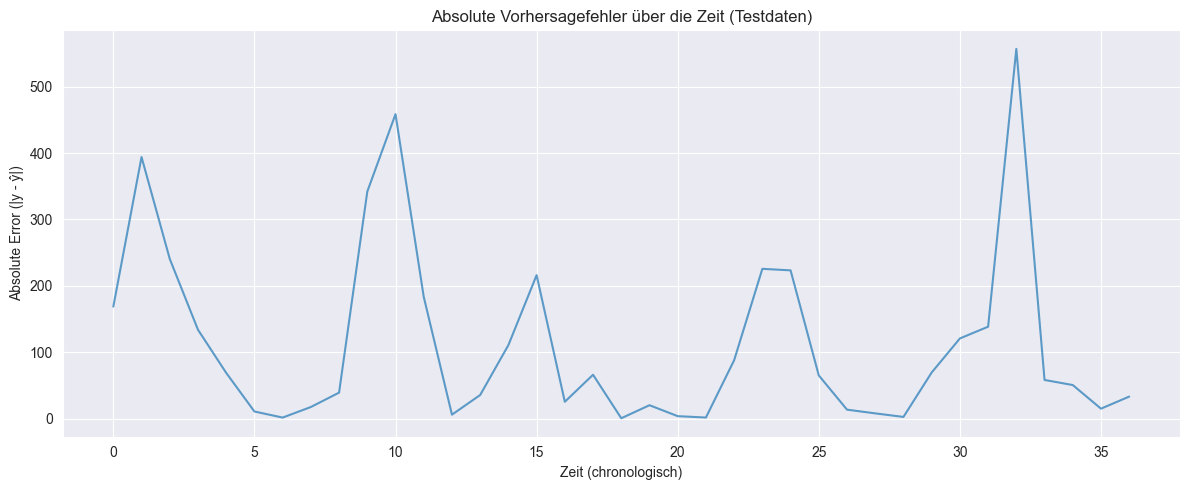

In [93]:
# Fehler über die Zeit visualisieren
plt.figure(figsize=(12, 5))
plt.plot(
    range(len(df_errors)),
    df_errors["abs_error"],
    label="Absolute Error",
    alpha=0.7
)
plt.ylabel("Absolute Error (|y - ŷ|)")
plt.xlabel("Zeit (chronologisch)")
plt.title("Absolute Vorhersagefehler über die Zeit (Testdaten)")
plt.tight_layout()
plt.show()

In [94]:
#Fehler nach Jahreszeit analysieren (Sommer vs. Rest)
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_errors["Season"] = df_errors["Month"].apply(season_from_month)

In [95]:
season_error = (
    df_errors
    .groupby("Season")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(season_error)

Season
Summer    223.25939
Fall      49.175285
Spring    43.610332
Winter     8.680148
Name: abs_error, dtype: Float64


In [96]:
#Analyse der Extremmonate (wo schwächelt das Modell?)
df_errors.nlargest(10, "abs_error")[
    ["Year", "Month", "y_true", "y_pred", "abs_error"]
]


,Year,Month,y_true,y_pred,abs_error
32,2022,8,935,378.199615,556.800385
10,2019,8,126,584.513550,458.51355
1,2018,7,684,290.071838,393.928162
9,2019,7,155,496.927490,341.92749
2,2018,8,766,1006.594055,240.594055
23,2021,7,784,558.335632,225.664368
24,2021,8,263,486.371613,223.371613
15,2020,7,115,331.171661,216.171661
11,2019,9,95,278.578125,183.578125
0,2018,6,327,158.228409,168.771591


# 15. Export der Modelle/Plots

In [97]:
model_path = "../models/xgboost_final_model_v4_bc.joblib"
joblib.dump(final_model, model_path)

print("Modell erfolgreich gespeichert:", model_path)

Modell erfolgreich gespeichert: ../models/xgboost_final_model_v4_bc.joblib


In [98]:
#feature namen seperat speichern
feature_path = "../models/xgboost_features_v4_bc.joblib"
joblib.dump(list(X_final.columns), feature_path)

print("Feature-Liste gespeichert.")

Feature-Liste gespeichert.
